In [11]:
import os
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_style('ticks')
from scipy import interpolate
from statistics import mean
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy import odr, stats

# constants
c = 299792458 # speed of light in vacuum
e0 = 8.8541878128e-12 # vacuum permittivity
me = 9.1093837015e-31 # mass of the electron
qe = 1.602176634e-19 # charge of the electron
Na = 6.0221409e23 # Avogadro's number in mol-1
h = 6.62607015e-34 # J · s
hbar = h / (2 * np.pi)

markerlist = ['o','v','^','<','>','1','2','3','4','8','s','p','*','h','H','+','x','D','d','P','X']
markerlist = markerlist + markerlist + markerlist + markerlist + markerlist + markerlist + markerlist + markerlist

## Loading structural parameters

In [12]:
giwaxs_raw = pd.read_excel('Raw_data_tables.xlsx', sheet_name='raw_data')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
     display(giwaxs_raw)

,Solvent,Method,A(001),A(100),A(010),A(Side),cos$^{2}$X(001)$(a.u.)$,cos$^{2}$(100)$(a.u.)$,cos$^{2}$X(010)$(a.u.)$,S(001)$(a.u.)$,S(100)$(a.u.)$,S(010)$(a.u.)$,OOP(001)(%),IP(001)(%),OOP(100)(%),IP(100)(%),OOP(010)(%),IP(010)(%),q(001)ip,FWHM(001)ip,q(100)oop,FWHM(100)oop,q(100)ip,FWHM(100)ip,q(010)oop,FWHM(010)oop,q(010)ip,FWHM(010)ip
0,CB,I,99.384,66.492,1156.370,297.168,0.14,0.23,0.80,-0.29,-0.16,0.70,3.75,96.21,5.03,57.350,87.26,5.62,3.020000,0.32000,3.23000,1.41000,3.0800,0.92000,17.03000,2.750000,16.46000,1.44000
1,CB,I,29.578,116.556,960.906,327.454,0.16,0.21,0.76,-0.26,-0.18,0.64,4.64,90.74,6.02,72.490,82.43,10.65,3.070000,0.34000,3.19000,1.64000,3.0300,1.10000,16.97000,2.069000,16.34000,1.38000
2,CB,I,179.639,112.853,2253.120,920.991,0.12,0.24,0.73,-0.31,-0.14,0.60,2.18,97.79,6.06,58.460,78.17,10.71,3.019000,0.32000,3.19000,1.53000,3.1100,0.83000,17.05000,2.036600,16.56000,1.81000
3,CB,II,70.164,191.242,2852.860,1306.730,0.13,0.23,0.75,-0.31,-0.16,0.63,2.75,97.22,7.38,66.450,84.47,15.51,3.050000,0.31000,3.21000,1.45000,3.1200,0.79000,17.07000,1.990000,16.59000,2.02000
4,CB,II,149.811,101.507,2198.191,797.355,0.12,0.28,0.75,-0.32,-0.08,0.63,1.53,98.45,9.84,50.730,83.30,15.76,2.950000,0.32300,3.22000,1.40000,3.1200,0.89100,16.97000,1.980000,16.50000,1.86000
5,CB,II,83.341,248.749,4102.112,1726.785,0.16,0.31,0.57,-0.26,-0.03,0.36,5.51,94.43,3.80,19.460,49.78,10.27,3.070000,0.25000,3.24000,0.72500,3.1100,0.61600,17.12000,1.550000,16.73000,2.06700
6,CB,III,64.412,66.892,901.569,210.839,0.11,0.23,0.81,-0.34,-0.16,0.72,1.67,98.31,6.66,68.690,90.48,9.50,3.010000,0.31000,3.28000,1.48000,3.1400,0.75000,17.06000,2.060000,16.52000,2.08000
7,CB,III,113.535,126.211,2740.319,1181.626,0.13,0.24,0.72,-0.31,-0.14,0.58,2.49,97.47,7.78,60.510,79.94,20.04,3.050000,0.32500,3.24000,1.59000,3.1400,0.86000,17.12000,2.110000,16.60000,2.01100
8,CB,III,129.441,104.800,1390.823,566.160,0.15,0.17,0.79,-0.28,-0.24,0.69,4.57,95.37,5.36,85.060,88.25,11.74,2.990000,0.31500,3.26000,1.63000,3.1100,0.70000,17.03000,2.060000,16.46000,1.40000
9,CB,IV,11.592,54.985,567.078,126.092,0.13,0.29,0.76,-0.30,-0.06,0.65,3.58,96.38,11.28,46.990,85.74,13.88,2.950000,0.28900,3.26000,0.84000,3.0200,0.63000,16.99000,1.590000,16.58000,2.18000


In [13]:
giwaxs_raw = pd.read_excel('Raw_data_tables.xlsx', sheet_name='raw_data')

# setting up derived structural parameters
giwaxs_raw['A(010)/A(100)(a.u.)'] = giwaxs_raw['A(010)'] / giwaxs_raw['A(100)']
giwaxs_raw['A(100)/A(Side)(a.u.)'] = giwaxs_raw['A(100)'] / giwaxs_raw['A(Side)']
giwaxs_raw['A(010)/A(Side)(a.u.)'] = giwaxs_raw['A(010)'] / giwaxs_raw['A(Side)']
giwaxs_raw['A(001)/A(Side)(a.u.)'] = giwaxs_raw['A(001)'] / giwaxs_raw['A(Side)']

# calculation of the paracrystalline disorder parameters, g
rows = range(np.shape(giwaxs_raw)[0])
q_100, fwhm_100 = [], []
q_010, fwhm_010 = [], []
q_001, fwhm_001 = [], []



for row in rows:
    data = giwaxs_raw.iloc[row,:]
    if data.Solvent == 'CB':
        q_100.append(data['q(100)ip'])
        fwhm_100.append(data['FWHM(100)ip'])
        q_010.append(data['q(010)oop'])
        fwhm_010.append(data['FWHM(010)oop'])
    if data.Solvent == 'oXy':
        q_100.append(data['q(100)oop'])
        fwhm_100.append(data['FWHM(100)oop'])
        q_010.append(data['q(010)ip'])
        fwhm_010.append(data['FWHM(010)ip'])
    if data.Solvent == 'CF':
        q_100.append(data['q(100)oop'])
        fwhm_100.append(data['FWHM(100)oop'])
        q_010.append(data['q(010)ip'])
        fwhm_010.append(data['FWHM(010)ip'])
    if data.Solvent == 'DCB':
        q_100.append(data['q(100)ip'])
        fwhm_100.append(data['FWHM(100)ip'])
        q_010.append(data['q(010)oop'])
        fwhm_010.append(data['FWHM(010)oop'])
    if data.Solvent == 'TL':
        q_100.append(data['q(100)oop'])
        fwhm_100.append(data['FWHM(100)oop'])
        q_010.append(data['q(010)ip'])
        fwhm_010.append(data['FWHM(010)ip'])

q_001 = giwaxs_raw['q(001)ip']
fwhm_001 = giwaxs_raw['FWHM(001)ip']

giwaxs_raw['g(100)(%)'] = np.sqrt(np.array(fwhm_100)/(2*np.pi*np.array(q_100)))*100
giwaxs_raw['g(010)(%)'] = np.sqrt(np.array(fwhm_010)/(2*np.pi*np.array(q_010)))*100
giwaxs_raw['g(001)(%)'] = np.sqrt(np.array(fwhm_001)/(2*np.pi*np.array(q_001)))*100

# calculation of averages and standard deviations
means = giwaxs_raw.groupby(['Solvent', 'Method']).mean().reset_index()
stds = giwaxs_raw.groupby(['Solvent', 'Method']).std().reset_index()


In [14]:
#CREAMOS UN ARCHIVO CON TODOS LOS DATOS DE A(hkl)/A(side) y g
# 1. Creamos un diccionario para que cada columna tenga su nombre
df_final = pd.DataFrame({
    'A(010)/A(100)(a.u.)': giwaxs_raw['A(010)/A(100)(a.u.)'],
    'A(100)/A(Side)(a.u.)': giwaxs_raw['A(100)/A(Side)(a.u.)'],
    'A(010)/A(Side)(a.u.)': giwaxs_raw['A(010)/A(Side)(a.u.)'],
    'A(001)/A(Side)(a.u.)': giwaxs_raw['A(001)/A(Side)(a.u.)'],
    'g(100)%':giwaxs_raw['g(100)(%)'],
    'g(010)%':giwaxs_raw['g(010)(%)'],
    'g(001)%':giwaxs_raw['g(001)(%)']
})

# 2. Guardamos directamente a un archivo Excel
# Nota: index=False evita que se guarde la columna de números (0, 1, 2...) de la izquierda
df_final.to_excel('mis_datos_giwaxs.xlsx', index=False)

print("¡Archivo Excel creado con éxito!")

¡Archivo Excel creado con éxito!


In [4]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(means)

,Solvent,Method,A(001),A(100),A(010),A(Side),cos$^{2}$X(001)$(a.u.)$,cos$^{2}$X(100)$(a.u.)$,cos$^{2}$X(010)$(a.u.)$,S(001)$(a.u.)$,S(100)$(a.u.)$,S(010)$(a.u.)$,OOP(001)(%),IP(001)(%),OOP(100)(%),IP(100)(%),OOP(010)(%),IP(010)(%),q(001)ip,FWHM(001)ip,q(100)oop,FWHM(100)oop,q(100)ip,FWHM(100)ip,q(010)oop,FWHM(010)oop,q(010)ip,FWHM(010)ip,A(010)/A(100)(a.u.),A(100)/A(Side)(a.u.),A(010)/A(Side)(a.u.),A(001)/A(Side)(a.u.),g(100)(%),g(010)(%),g(001)(%)
0,CB,I,102.867000,98.633667,1456.798667,515.204333,0.140000,0.226667,0.763333,-0.286667,-0.160000,6.466667e-01,3.523333,94.913333,5.703333,62.766667,82.620000,8.993333,3.036333,0.326667,3.203333,1.526667,3.073333,0.950000,17.016667,2.285200,16.453333,1.543333,15.200120,0.234078,3.090728,0.206605,22.150153,14.583080,13.083640
1,CB,II,101.105333,180.499333,3051.054333,1276.956667,0.136667,0.273333,0.690000,-0.296667,-0.090000,5.400000e-01,3.263333,96.700000,7.006667,45.546667,72.516667,13.846667,3.023333,0.294333,3.223333,1.191667,3.116667,0.765667,17.053333,1.840000,16.606667,1.982333,17.688023,0.139236,2.438546,0.096614,19.716263,13.084111,12.434624
2,CB,III,102.462667,99.301000,1677.570333,652.875000,0.130000,0.213333,0.773333,-0.310000,-0.180000,6.633333e-01,2.910000,97.050000,6.600000,71.420000,86.223333,13.760000,3.016667,0.316667,3.260000,1.566667,3.130000,0.770000,17.070000,2.076667,16.526667,1.830333,16.153798,0.203061,3.017267,0.210072,19.767502,13.914512,12.924803
3,CB,IV,73.740500,73.619000,1335.971500,531.666000,0.115000,0.270000,0.735000,-0.325000,-0.090000,6.050000e-01,2.350000,97.620000,9.715000,53.360000,82.250000,17.550000,3.045000,0.324500,3.270000,1.160000,3.135000,0.805000,17.044000,1.770000,16.585000,2.070000,16.564772,0.267250,3.371574,0.118461,20.064060,12.838488,12.997439
4,CF,I,17.199667,235.063333,1475.334333,582.672667,0.086667,0.656667,0.386667,-0.373333,0.483333,8.333333e-02,0.780000,99.210000,59.293333,10.983333,22.080000,25.220000,2.886667,2.000000,3.286667,0.630000,3.040000,0.700000,16.793333,2.526667,16.556667,2.650000,10.676067,0.341723,2.821331,0.027083,17.070339,15.947946,33.119190
5,CF,II,4.067667,49.696333,602.033000,189.740667,0.113333,0.643333,0.343333,-0.330000,0.470000,1.000000e-02,2.490000,97.480000,57.273333,7.113333,15.290000,27.926667,2.790000,0.740000,3.311333,0.406667,3.126667,0.796667,16.906667,2.426667,16.663333,2.596667,11.598816,0.317026,3.178734,0.022939,13.953723,15.717347,19.582071
6,CF,III,15.682667,85.422000,1015.376333,613.819667,0.123333,0.626667,0.426667,-0.316667,0.443333,1.400000e-01,2.413333,97.553333,52.270000,10.271333,33.046667,36.486667,2.920000,2.023333,3.276667,0.976667,3.053333,0.690000,16.830000,2.563333,16.613333,2.706667,11.410142,0.151691,1.584446,0.031329,21.780543,16.096825,32.982484
7,CF,IV,12.106667,179.218333,1159.399667,580.328667,0.120000,0.613333,0.350000,-0.320000,0.423333,2.666667e-02,2.246667,97.723333,52.433333,7.260000,16.743333,28.250000,2.920000,2.266667,3.246667,0.596667,3.063333,0.673333,16.880000,2.396667,16.706667,2.516667,6.673960,0.306940,2.045317,0.022760,16.762213,15.482808,35.155266
8,DCB,I,5.609667,13.102667,151.268667,43.951333,0.096667,0.153333,0.783333,-0.356667,-0.273333,7.100000e-01,0.963333,99.016667,4.746667,95.206667,83.076667,6.130000,2.996667,0.366000,3.209667,0.440000,3.046800,0.319133,17.046100,1.616333,16.453333,1.812667,11.921703,0.301175,3.577154,0.131881,12.910206,12.284257,13.932175
9,DCB,II,9.441667,24.350000,292.254667,78.908333,0.150000,0.226667,0.696667,-0.276667,-0.153333,5.466667e-01,4.676667,95.273333,8.216667,68.820000,74.570000,12.906667,2.987000,0.449067,3.163333,0.620667,3.064167,0.295313,17.119267,1.619467,16.749667,1.949467,12.114152,0.313442,3.747000,0.122966,12.366436,12.270218,15.390544


In [14]:
# --- 1. PRE-PROCESAMIENTO DE DATOS (REDONDEO Y FORZADO) ---

# Identificamos las columnas de datos
parameters = [col for col in means.columns if col not in ['Solvent', 'Method']]

for df in [means, stds]:
    for col in parameters:
        # PASO A: Redondeamos a 1 decimal (redondeo de Excel)
        df[col] = df[col].round(2)
        
        # PASO B: Si después de redondear el valor es 0.0, lo forzamos a 0.1
        # (Esto elimina tanto el 0.0 como el -0.0)
        #df.loc[df[col] == 0.0, col] = 0.1

In [15]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
     display(means)

,Solvent,Method,A(001),A(100),A(010),A(Side),cos$^{2}$X(001)$(a.u.)$,cos$^{2}$X(100)$(a.u.)$,cos$^{2}$X(010)$(a.u.)$,S(001)$(a.u.)$,S(100)$(a.u.)$,S(010)$(a.u.)$,OOP(001)(%),IP(001)(%),OOP(100)(%),IP(100)(%),OOP(010)(%),IP(010)(%),q(001)ip,FWHM(001)ip,q(100)oop,FWHM(100)oop,q(100)ip,FWHM(100)ip,q(010)oop,FWHM(010)oop,q(010)ip,FWHM(010)ip,A(010)/A(100)(a.u.),A(100)/A(Side)(a.u.),A(010)/A(Side)(a.u.),A(001)/A(Side)(a.u.),g(100)(%),g(010)(%),g(001)(%)
0,CB,I,102.87,98.63,1456.80,515.20,0.14,0.23,0.76,-0.29,-0.16,0.65,3.52,94.91,5.70,62.77,82.62,8.99,3.04,0.33,3.20,1.53,3.07,0.95,17.02,2.29,16.45,1.54,15.20,0.23,3.09,0.21,22.15,14.58,13.08
1,CB,II,101.11,180.50,3051.05,1276.96,0.14,0.27,0.69,-0.30,-0.09,0.54,3.26,96.70,7.01,45.55,72.52,13.85,3.02,0.29,3.22,1.19,3.12,0.77,17.05,1.84,16.61,1.98,17.69,0.14,2.44,0.10,19.72,13.08,12.43
2,CB,III,102.46,99.30,1677.57,652.88,0.13,0.21,0.77,-0.31,-0.18,0.66,2.91,97.05,6.60,71.42,86.22,13.76,3.02,0.32,3.26,1.57,3.13,0.77,17.07,2.08,16.53,1.83,16.15,0.20,3.02,0.21,19.77,13.91,12.92
3,CB,IV,73.74,73.62,1335.97,531.67,0.12,0.27,0.74,-0.32,-0.09,0.60,2.35,97.62,9.72,53.36,82.25,17.55,3.04,0.32,3.27,1.16,3.14,0.80,17.04,1.77,16.58,2.07,16.56,0.27,3.37,0.12,20.06,12.84,13.00
4,CF,I,17.20,235.06,1475.33,582.67,0.09,0.66,0.39,-0.37,0.48,0.08,0.78,99.21,59.29,10.98,22.08,25.22,2.89,2.00,3.29,0.63,3.04,0.70,16.79,2.53,16.56,2.65,10.68,0.34,2.82,0.03,17.07,15.95,33.12
5,CF,II,4.07,49.70,602.03,189.74,0.11,0.64,0.34,-0.33,0.47,0.01,2.49,97.48,57.27,7.11,15.29,27.93,2.79,0.74,3.31,0.41,3.13,0.80,16.91,2.43,16.66,2.60,11.60,0.32,3.18,0.02,13.95,15.72,19.58
6,CF,III,15.68,85.42,1015.38,613.82,0.12,0.63,0.43,-0.32,0.44,0.14,2.41,97.55,52.27,10.27,33.05,36.49,2.92,2.02,3.28,0.98,3.05,0.69,16.83,2.56,16.61,2.71,11.41,0.15,1.58,0.03,21.78,16.10,32.98
7,CF,IV,12.11,179.22,1159.40,580.33,0.12,0.61,0.35,-0.32,0.42,0.03,2.25,97.72,52.43,7.26,16.74,28.25,2.92,2.27,3.25,0.60,3.06,0.67,16.88,2.40,16.71,2.52,6.67,0.31,2.05,0.02,16.76,15.48,35.16
8,DCB,I,5.61,13.10,151.27,43.95,0.10,0.15,0.78,-0.36,-0.27,0.71,0.96,99.02,4.75,95.21,83.08,6.13,3.00,0.37,3.21,0.44,3.05,0.32,17.05,1.62,16.45,1.81,11.92,0.30,3.58,0.13,12.91,12.28,13.93
9,DCB,II,9.44,24.35,292.25,78.91,0.15,0.23,0.70,-0.28,-0.15,0.55,4.68,95.27,8.22,68.82,74.57,12.91,2.99,0.45,3.16,0.62,3.06,0.30,17.12,1.62,16.75,1.95,12.11,0.31,3.75,0.12,12.37,12.27,15.39


In [16]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(stds)


,Solvent,Method,A(001),A(100),A(010),A(Side),cos$^{2}$X(001)$(a.u.)$,cos$^{2}$X(100)$(a.u.)$,cos$^{2}$X(010)$(a.u.)$,S(001)$(a.u.)$,S(100)$(a.u.)$,S(010)$(a.u.)$,OOP(001)(%),IP(001)(%),OOP(100)(%),IP(100)(%),OOP(010)(%),IP(010)(%),q(001)ip,FWHM(001)ip,q(100)oop,FWHM(100)oop,q(100)ip,FWHM(100)ip,q(010)oop,FWHM(010)oop,q(010)ip,FWHM(010)ip,A(010)/A(100)(a.u.),A(100)/A(Side)(a.u.),A(010)/A(Side)(a.u.),A(001)/A(Side)(a.u.),g(100)(%),g(010)(%),g(001)(%)
0,CB,I,75.09,27.90,696.53,351.75,0.02,0.02,0.04,0.03,0.02,0.05,1.25,3.70,0.58,8.44,4.55,2.92,0.03,0.01,0.02,0.12,0.04,0.14,0.04,0.40,0.11,0.23,6.16,0.12,0.74,0.12,1.74,1.26,0.17
1,CB,II,42.69,74.21,967.31,465.43,0.02,0.04,0.10,0.03,0.07,0.16,2.04,2.06,3.04,23.92,19.70,3.10,0.06,0.04,0.02,0.40,0.01,0.14,0.08,0.25,0.12,0.11,3.52,0.01,0.29,0.08,1.81,0.94,0.94
2,CB,III,33.90,30.04,952.32,491.17,0.02,0.04,0.05,0.03,0.05,0.07,1.49,1.51,1.21,12.50,5.55,5.55,0.03,0.01,0.02,0.08,0.02,0.08,0.05,0.03,0.07,0.37,4.81,0.11,1.09,0.11,1.00,0.08,0.11
3,CB,IV,87.89,26.35,1087.38,573.57,0.02,0.03,0.04,0.04,0.04,0.06,1.74,1.75,2.21,9.01,4.94,5.19,0.13,0.05,0.01,0.45,0.16,0.25,0.08,0.25,0.01,0.16,8.84,0.24,1.59,0.04,2.61,0.90,0.72
4,CF,I,15.61,234.97,623.17,335.99,0.01,0.02,0.01,0.02,0.03,0.01,0.17,0.17,4.23,7.92,2.69,3.74,0.11,0.46,0.04,0.35,0.01,0.08,0.04,0.06,0.05,0.26,6.61,0.19,0.82,0.01,4.61,0.82,4.36
5,CF,II,2.12,23.55,411.98,127.25,0.02,0.08,0.04,0.04,0.12,0.06,1.51,1.52,13.39,3.09,2.72,14.25,0.24,0.54,0.01,0.06,0.08,0.18,0.02,0.02,0.05,0.40,4.48,0.17,0.14,0.00,1.07,1.20,6.36
6,CF,III,5.33,17.61,624.64,216.11,0.01,0.03,0.02,0.01,0.03,0.02,0.25,0.25,1.28,7.39,5.96,8.74,0.14,0.72,0.01,0.01,0.02,0.07,0.05,0.11,0.05,0.18,5.13,0.06,0.59,0.02,0.10,0.51,6.50
7,CF,IV,11.47,44.02,244.75,97.31,0.01,0.02,0.01,0.02,0.03,0.02,1.29,1.30,2.65,1.64,4.27,6.04,0.14,0.28,0.02,0.27,0.01,0.03,0.06,0.05,0.06,0.08,1.80,0.04,0.62,0.02,4.21,0.28,2.94
8,DCB,I,3.58,9.62,97.57,31.98,0.02,0.02,0.01,0.02,0.03,0.07,0.78,0.79,0.94,0.95,4.54,2.90,0.04,0.04,0.01,0.02,0.01,0.01,0.06,0.03,0.04,0.25,1.55,0.02,0.34,0.02,0.24,0.09,0.72
9,DCB,II,1.00,2.86,28.32,14.76,0.02,0.01,0.02,0.03,0.02,0.03,1.25,1.26,1.06,2.65,3.20,2.59,0.03,0.11,0.06,0.04,0.04,0.04,0.05,0.01,0.04,0.17,1.87,0.05,0.38,0.03,0.72,0.03,1.93


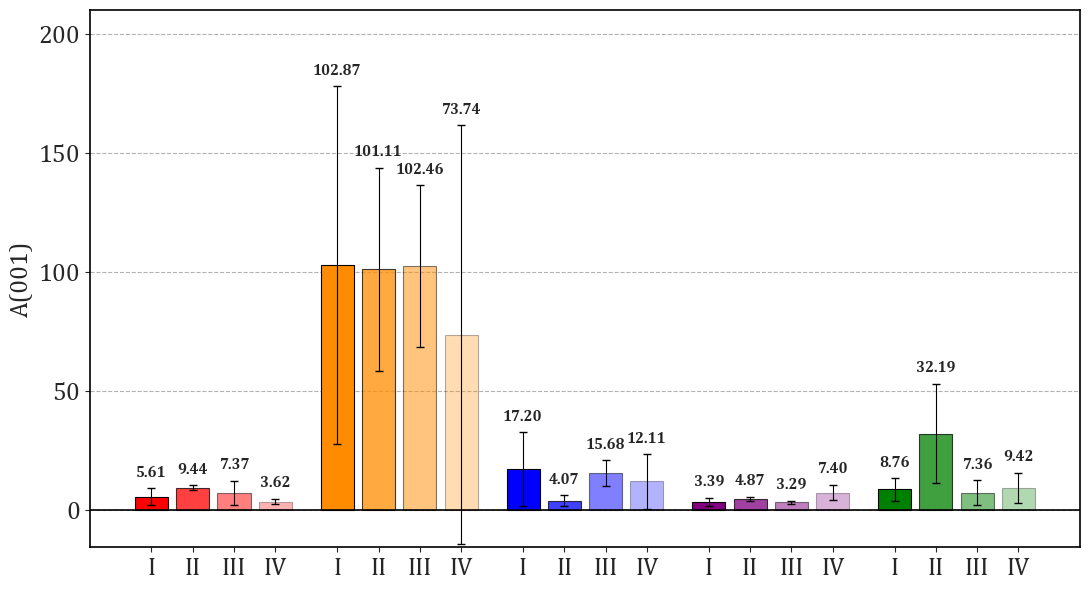

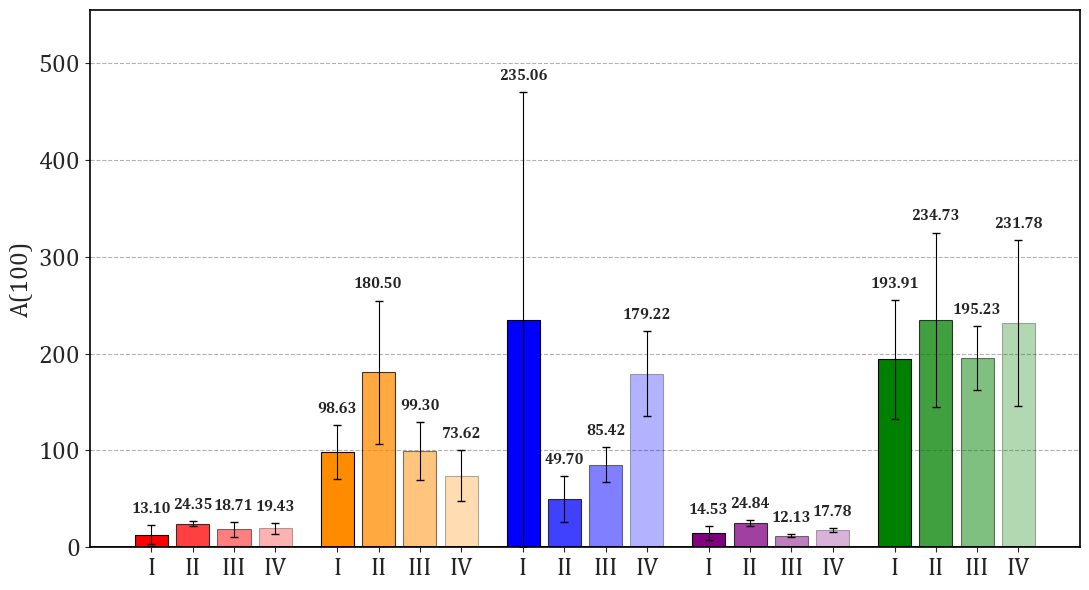

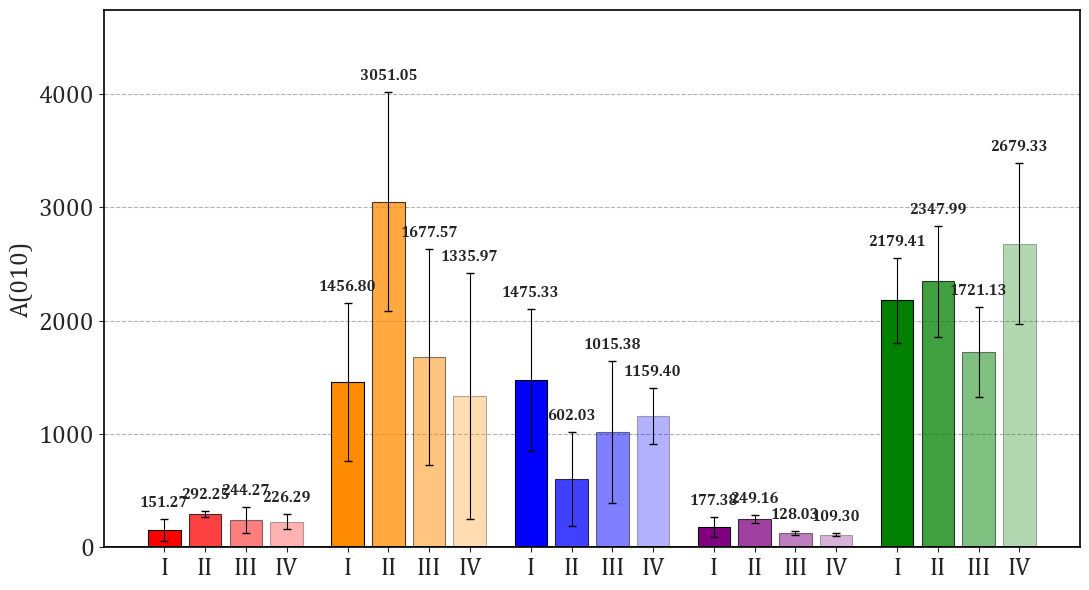

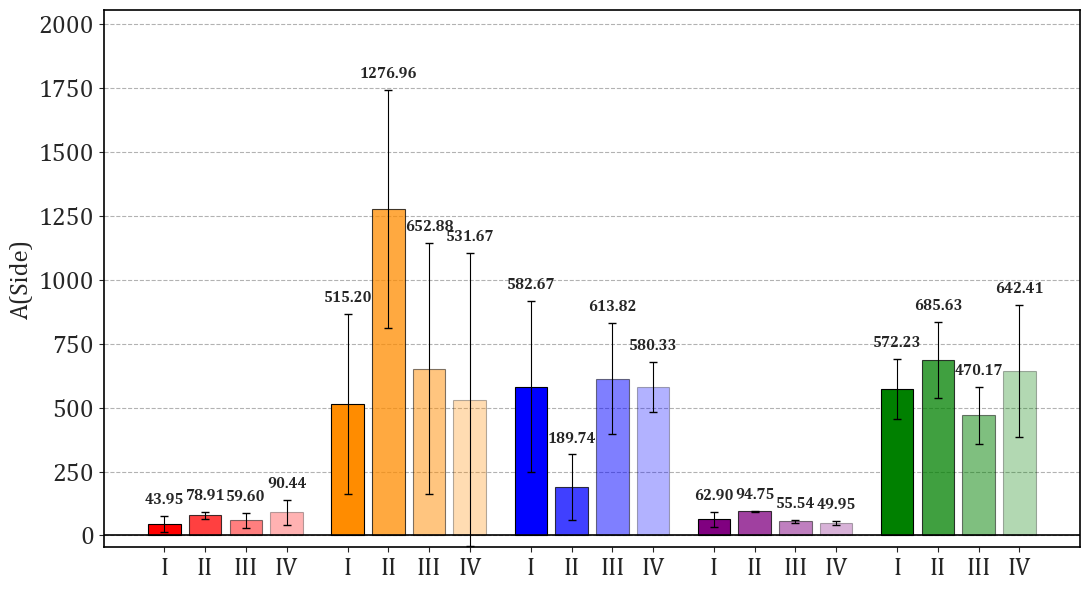

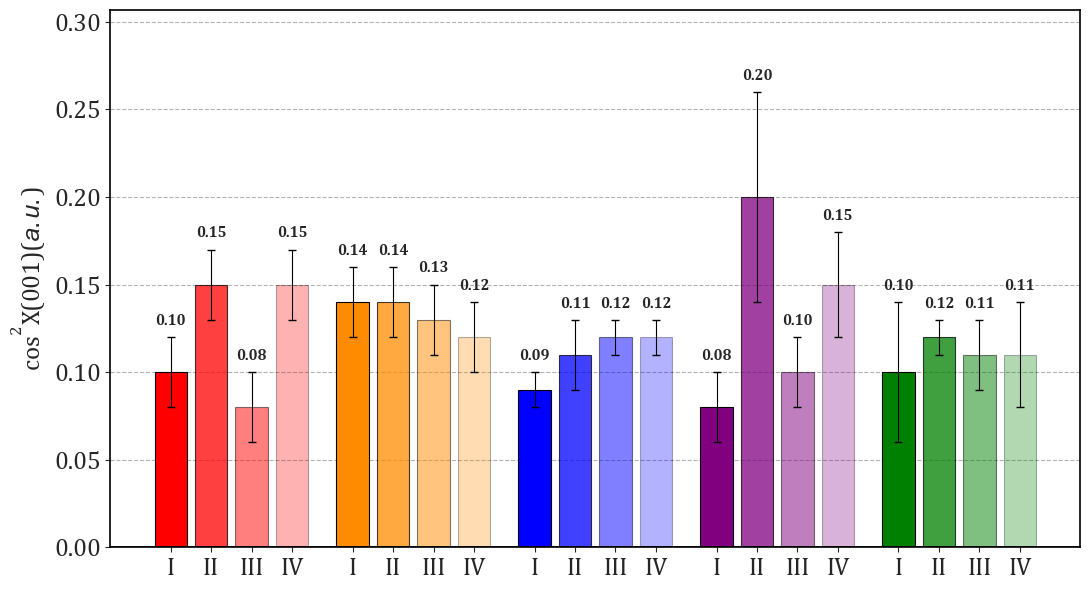

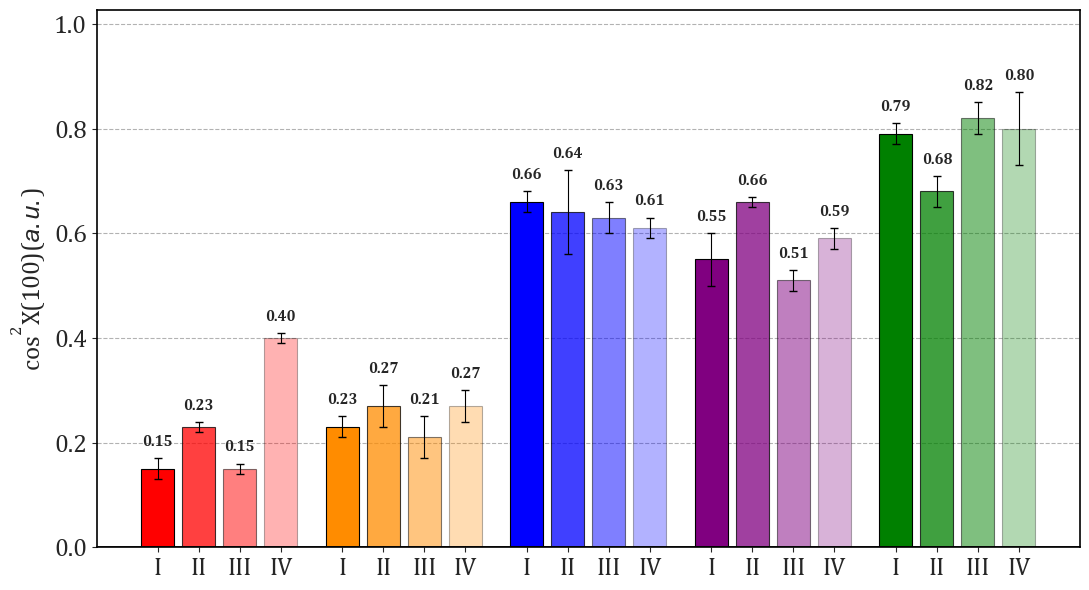

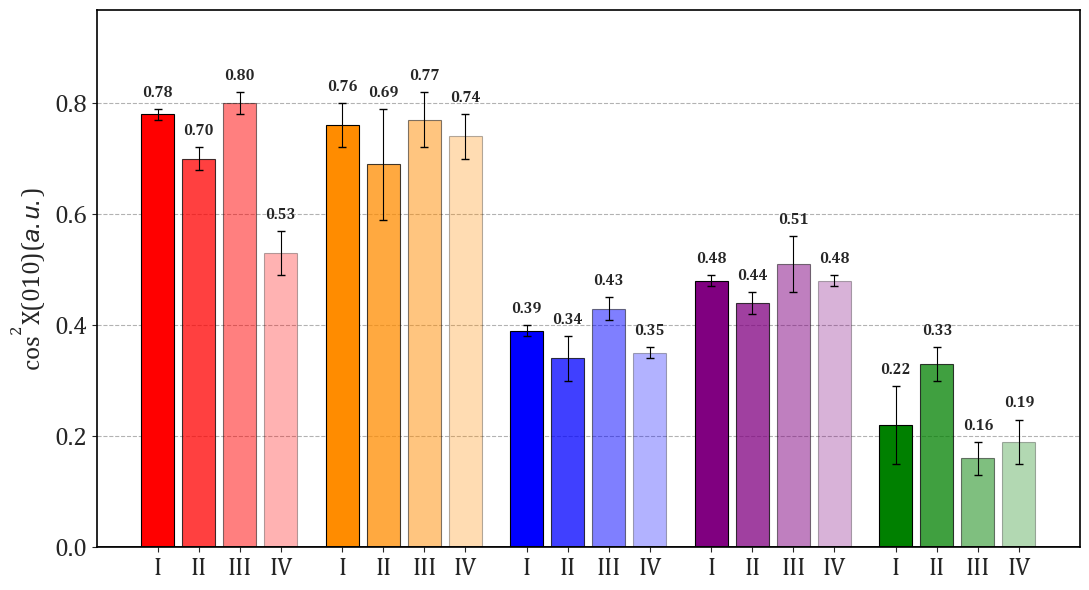

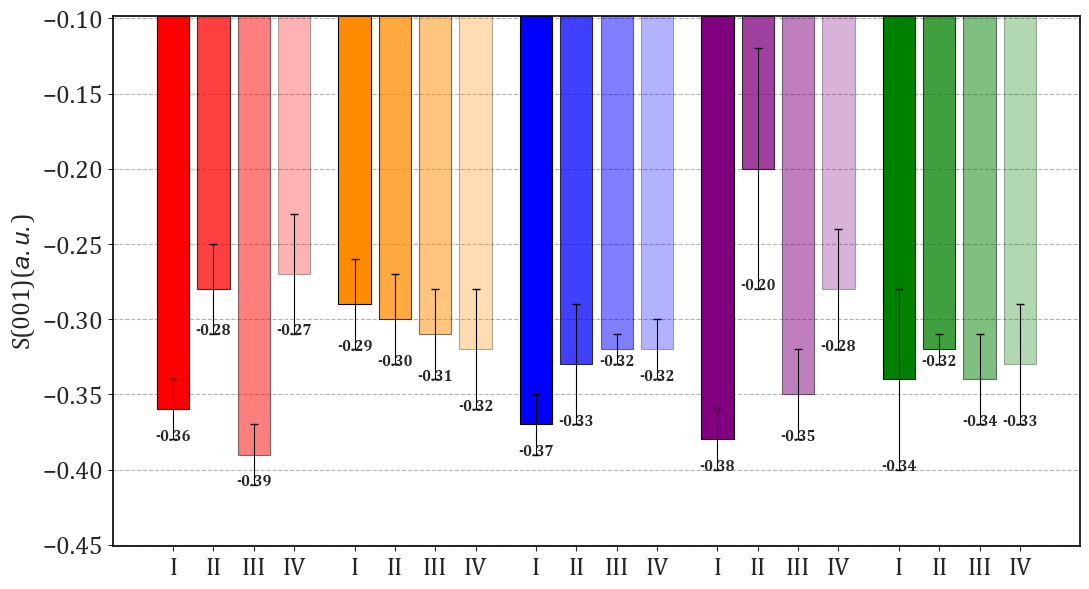

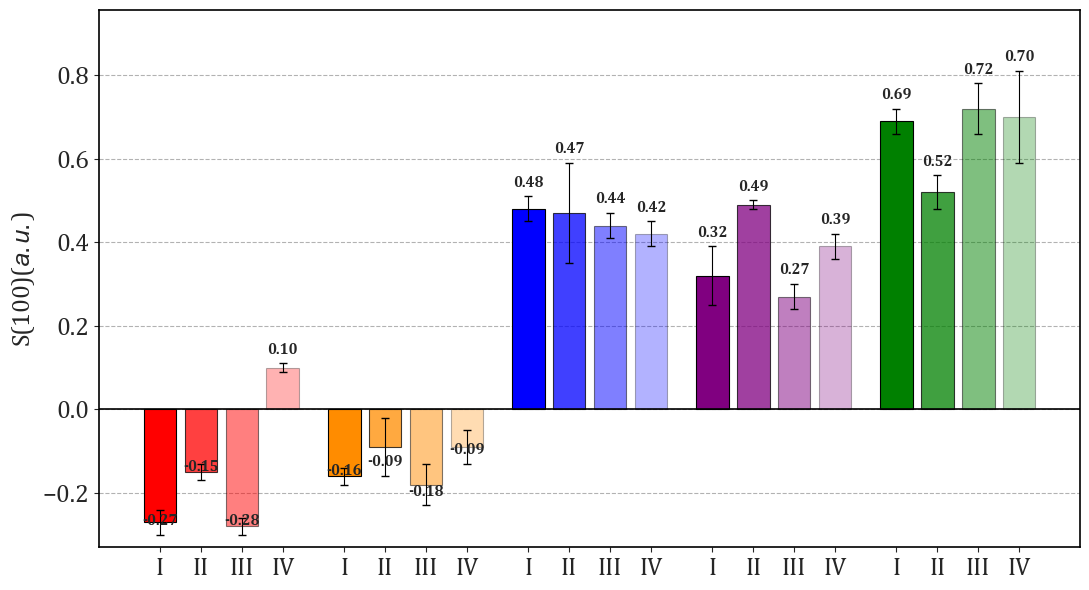

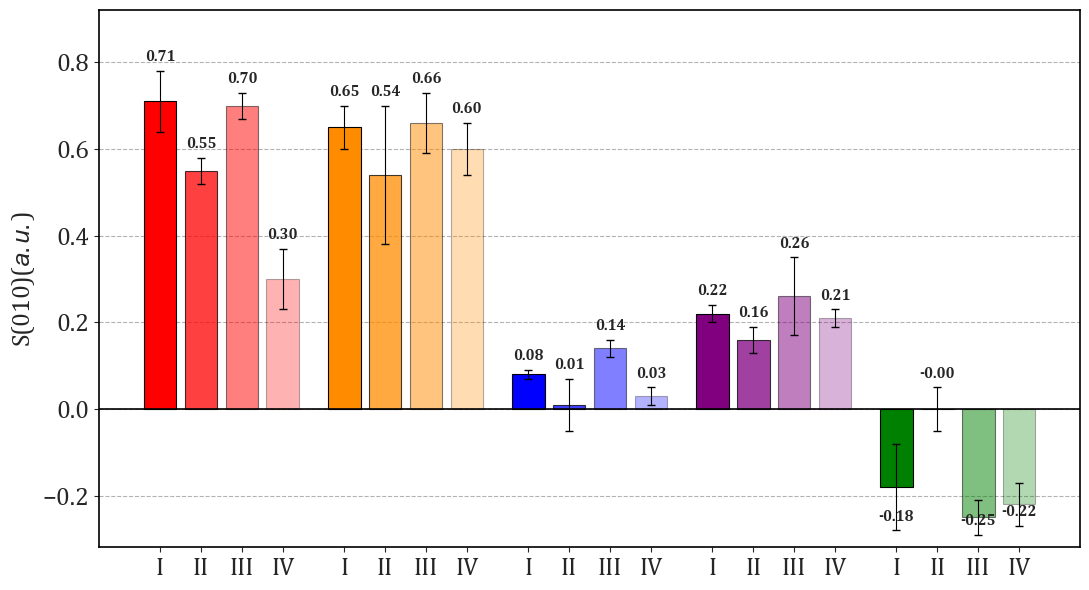

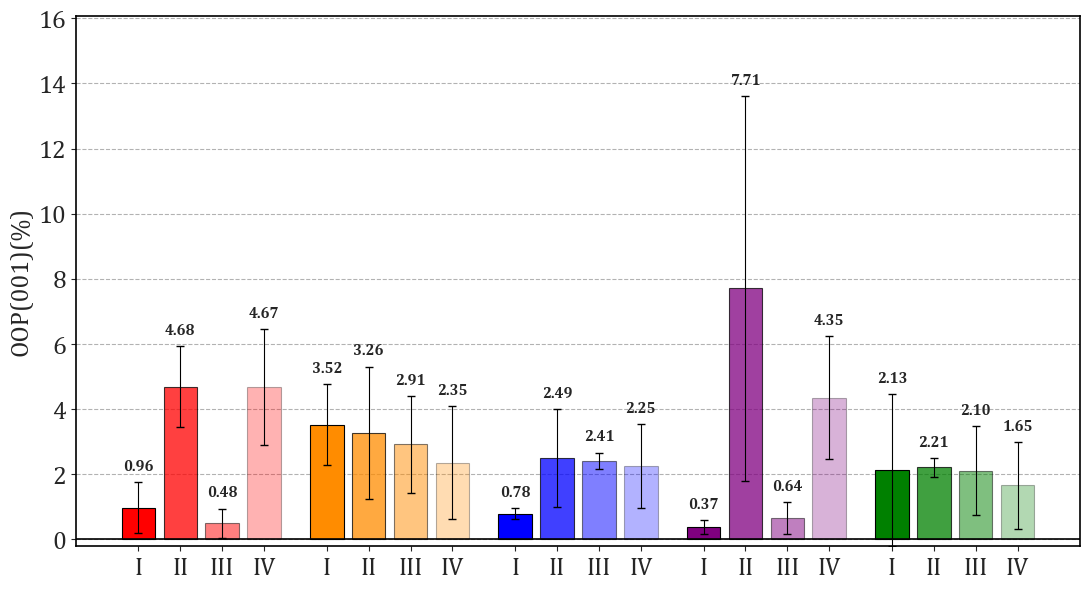

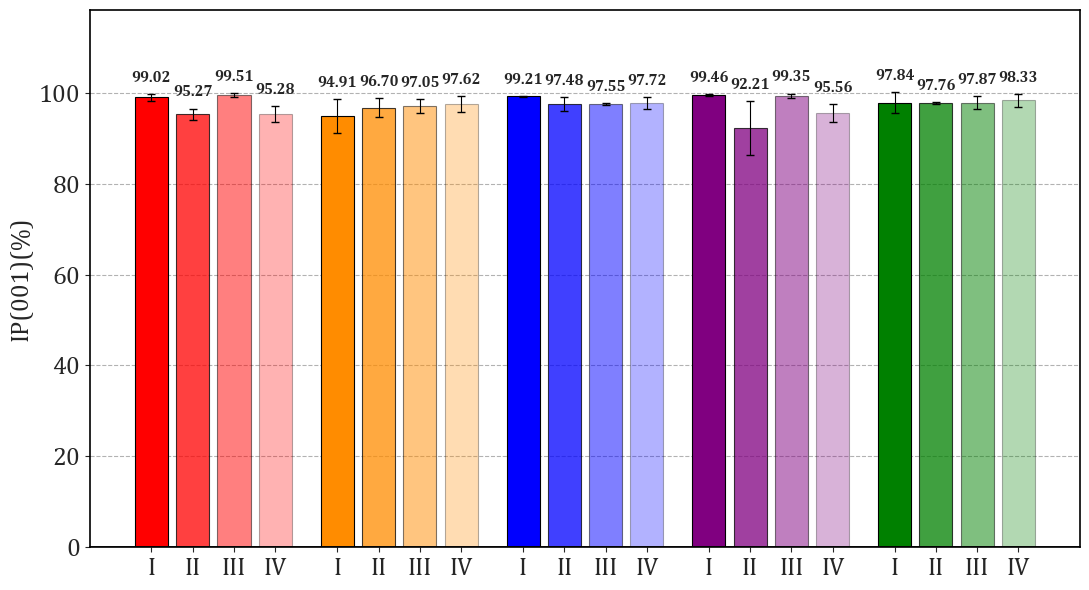

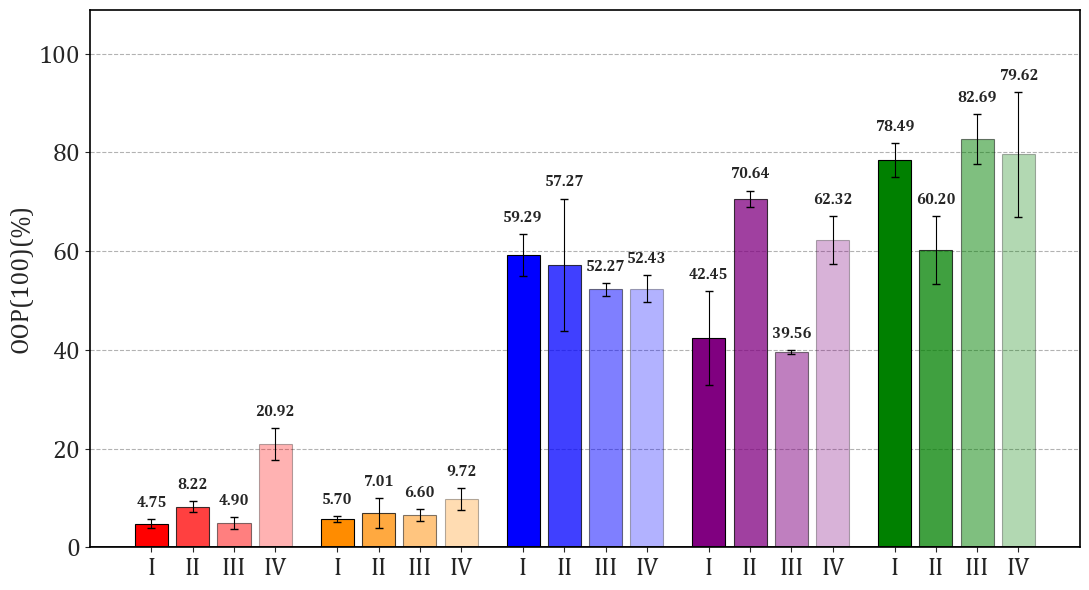

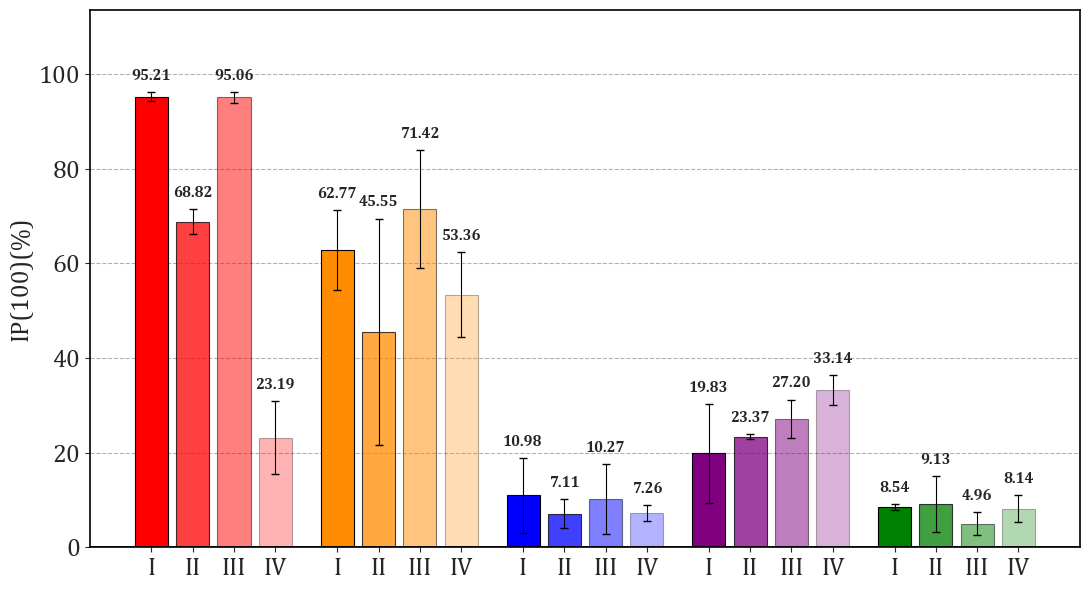

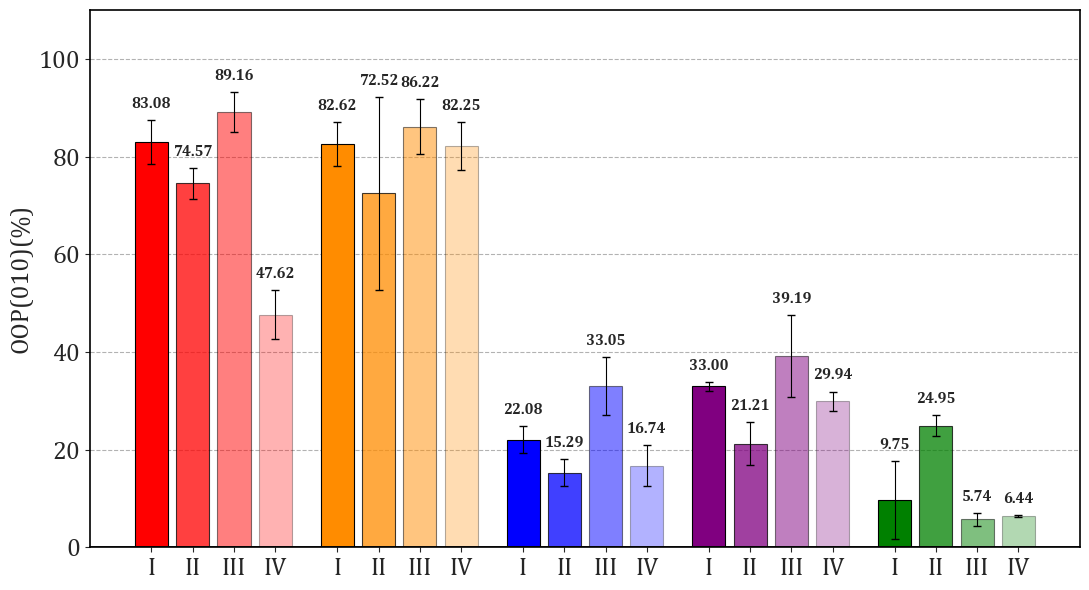

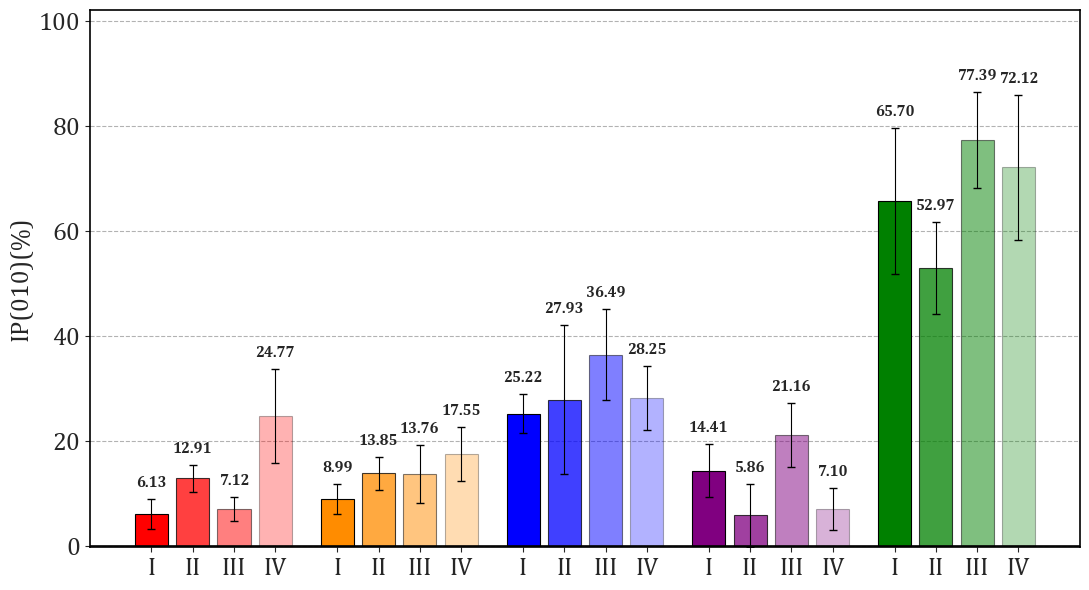

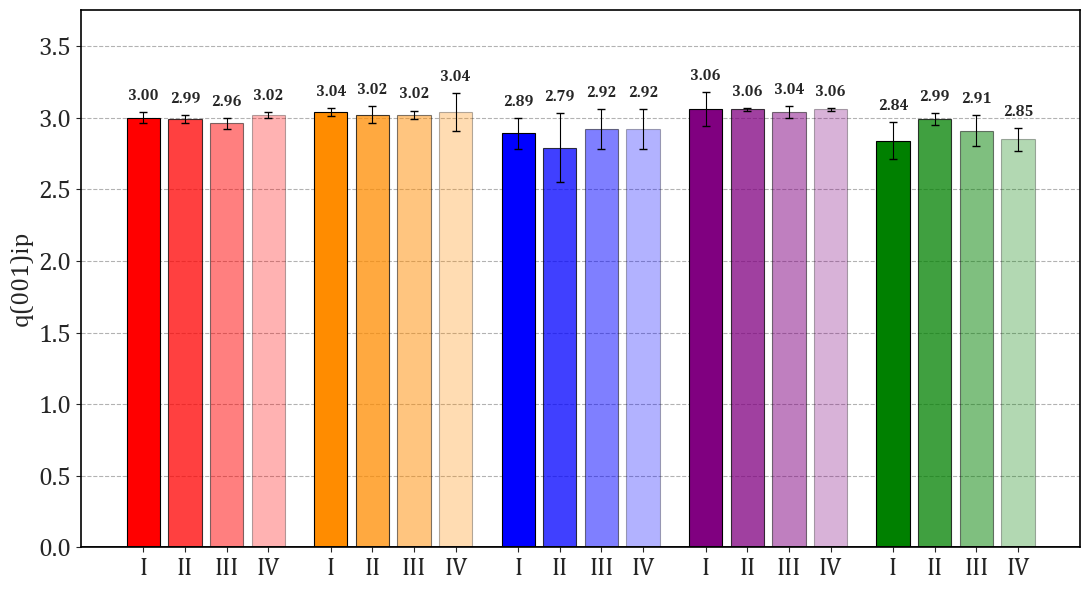

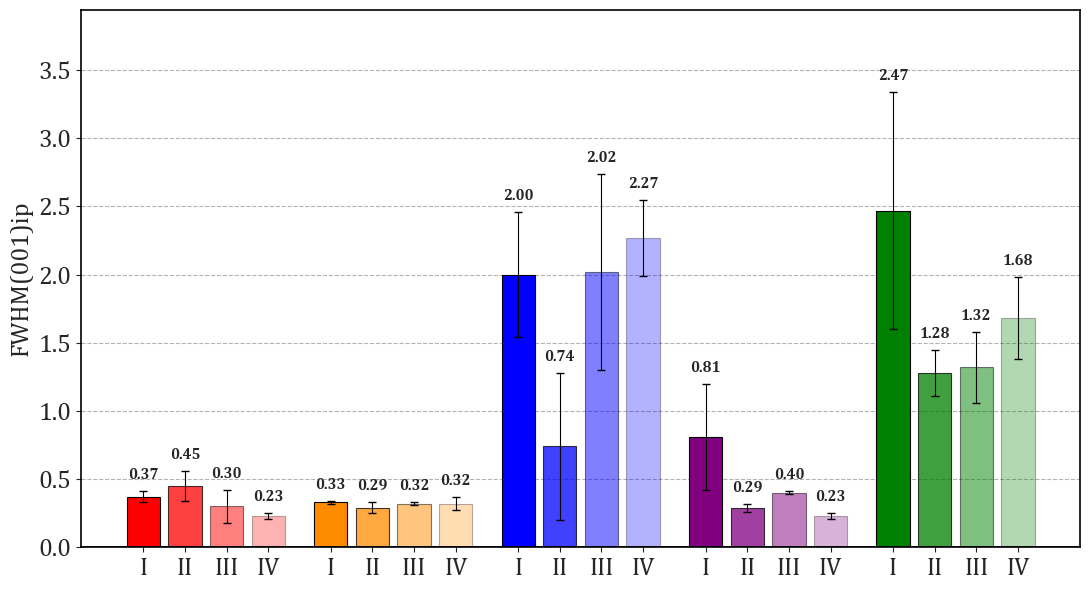

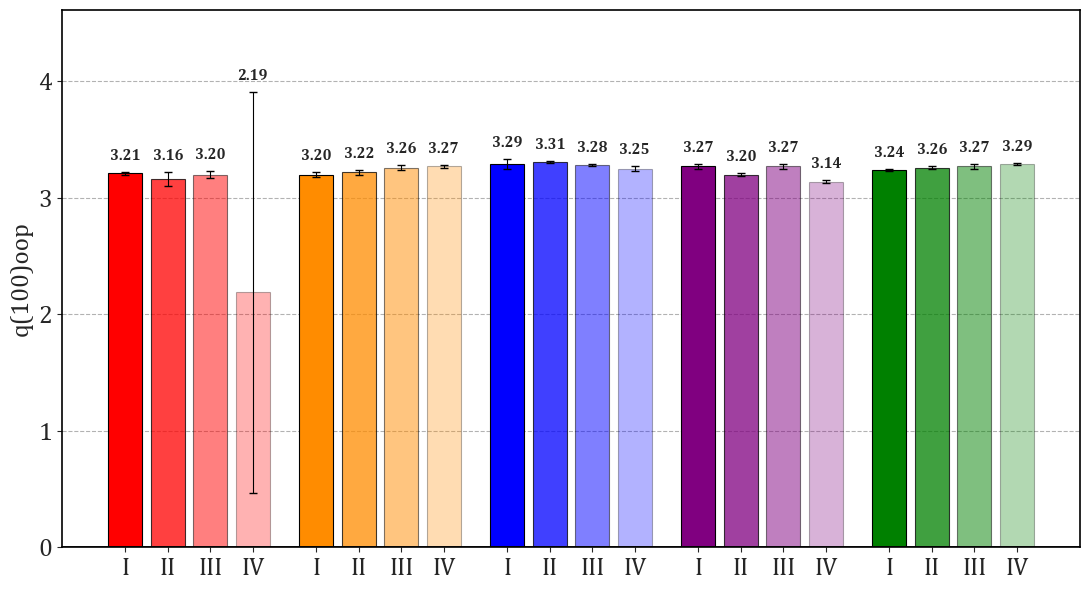

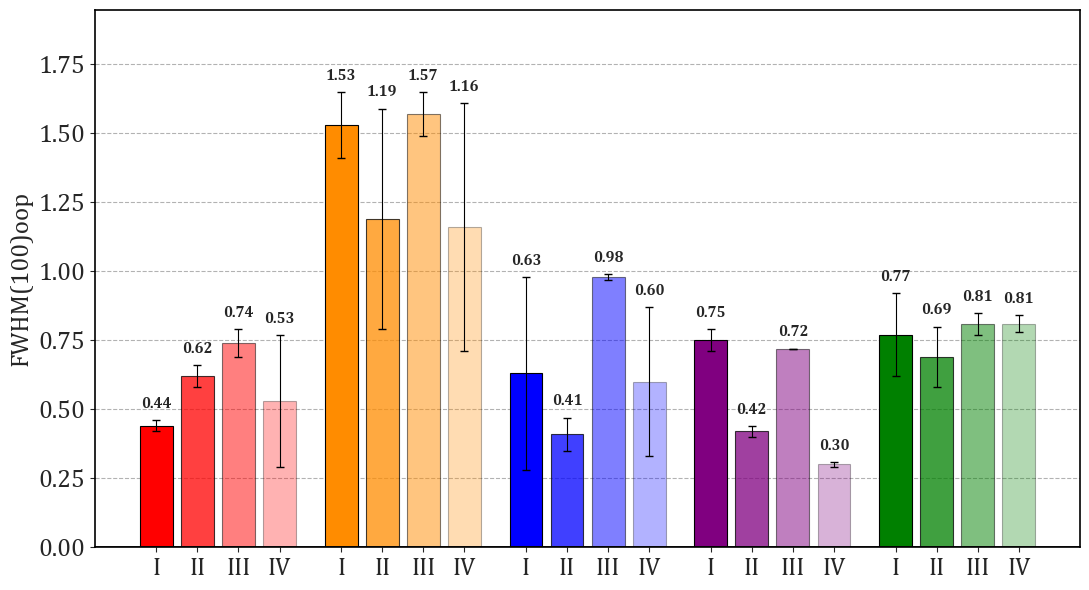

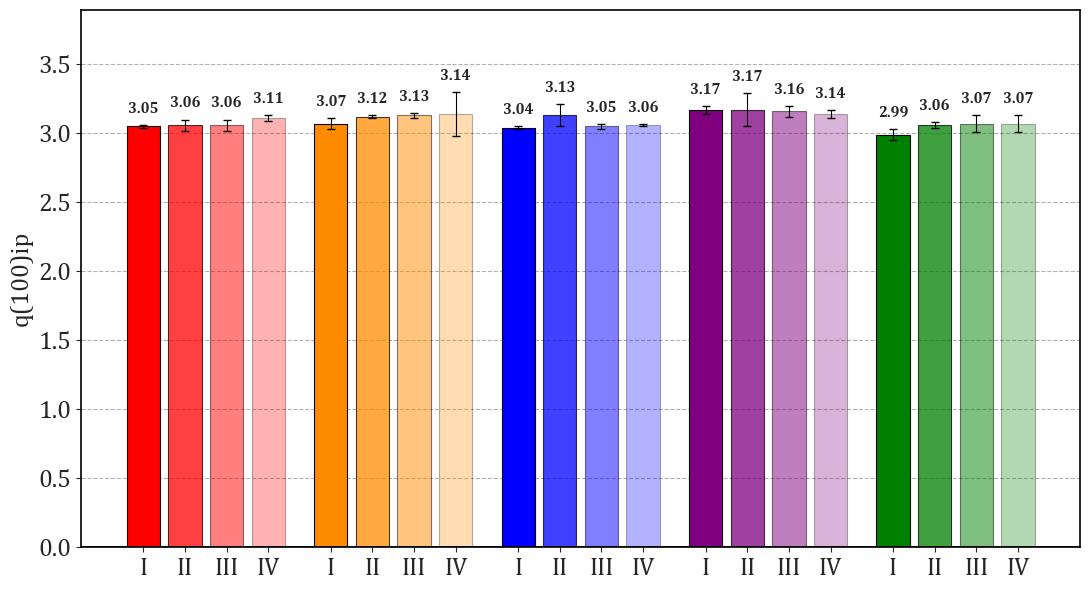

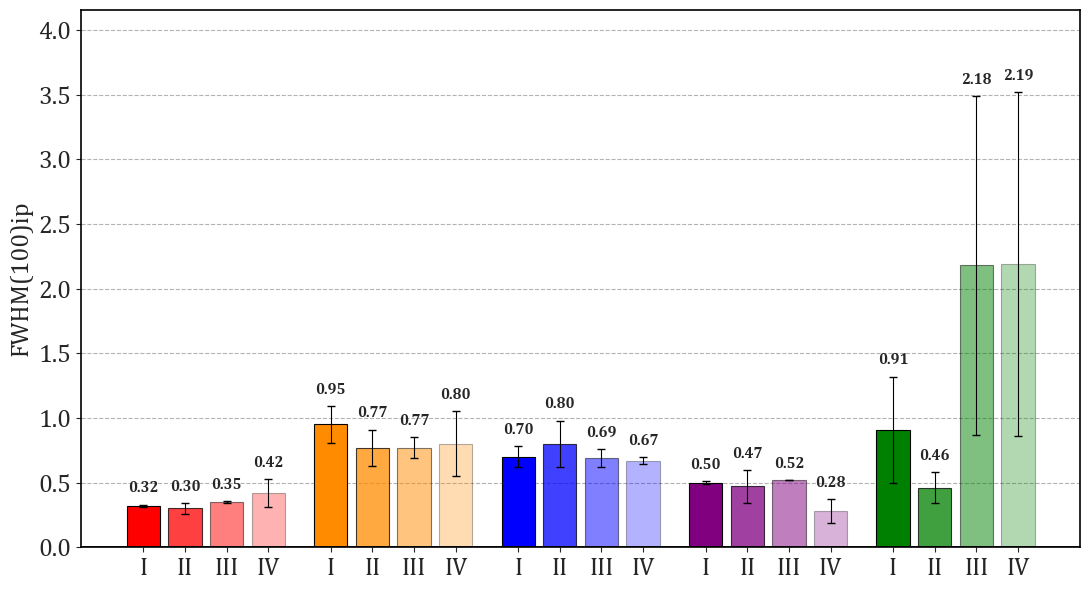

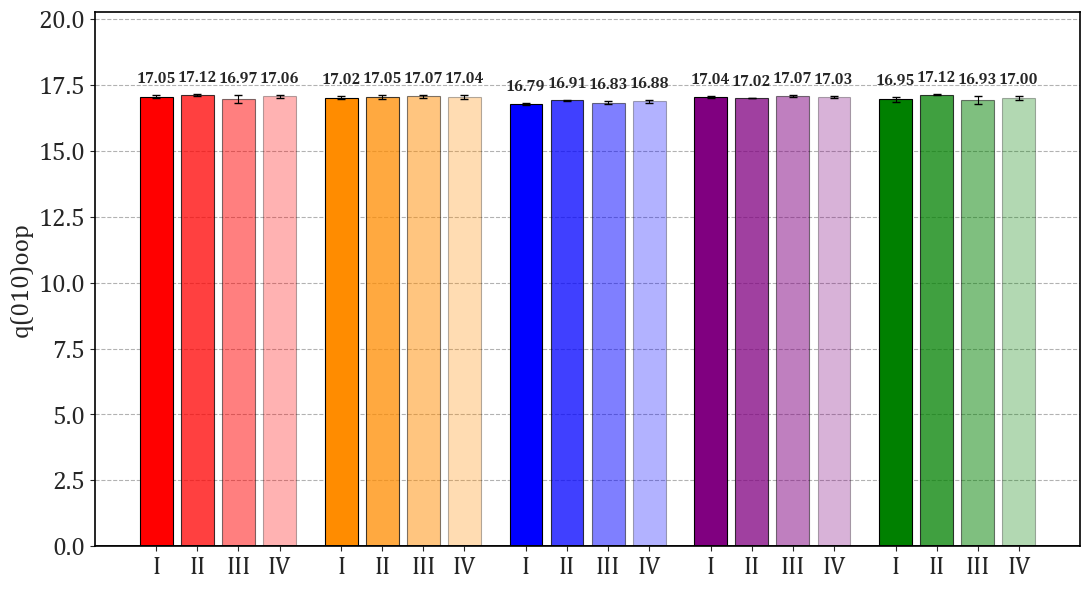

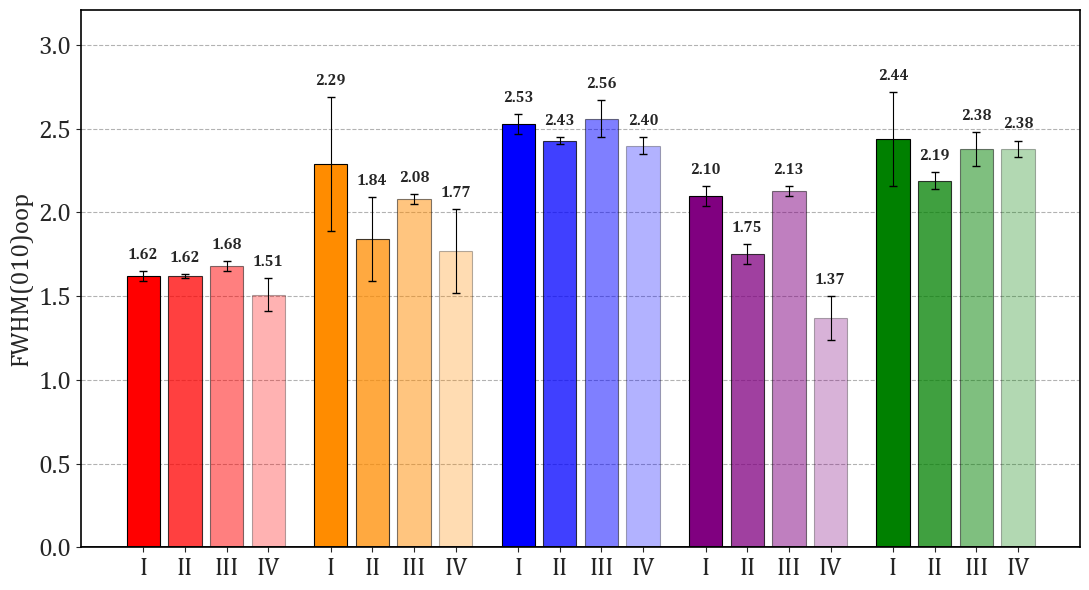

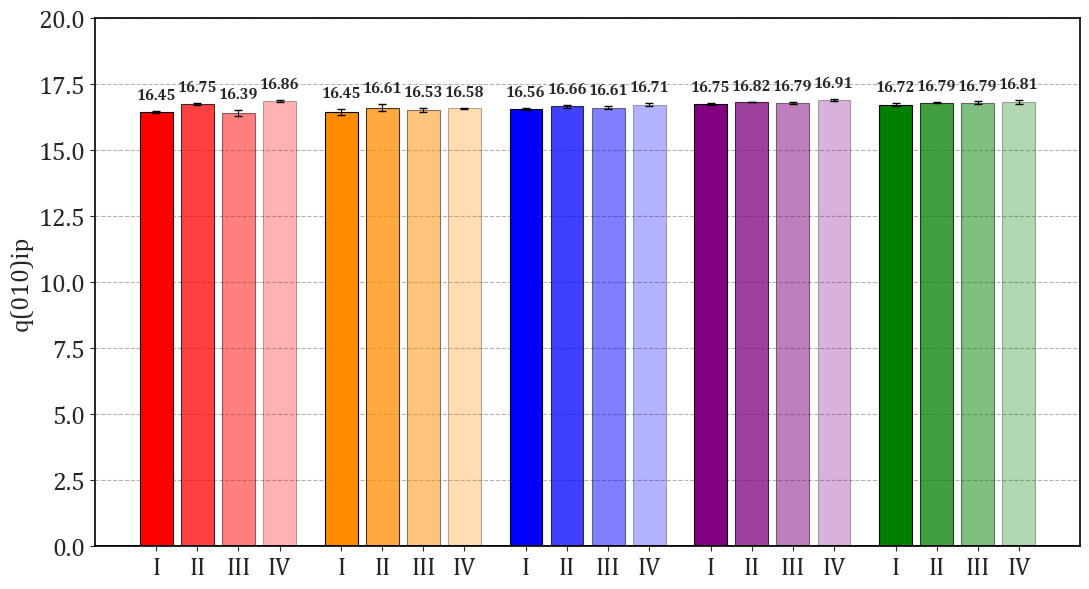

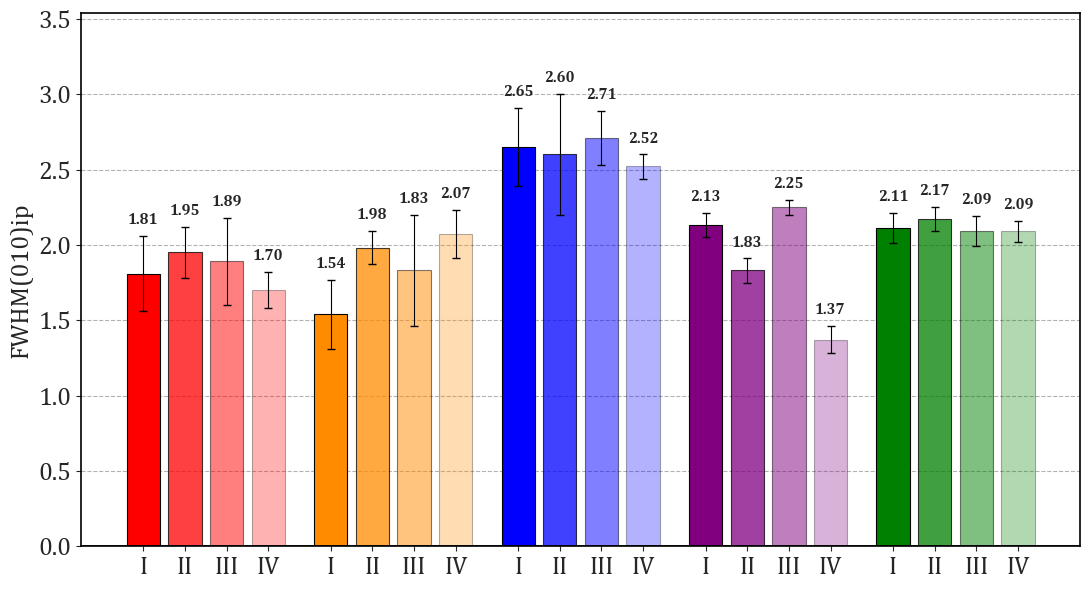

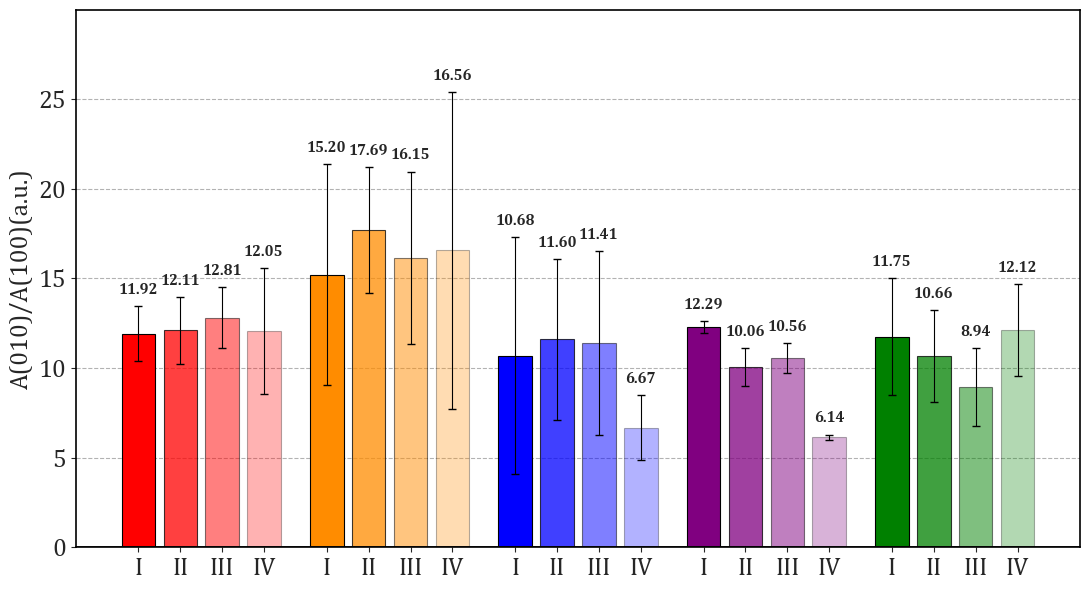

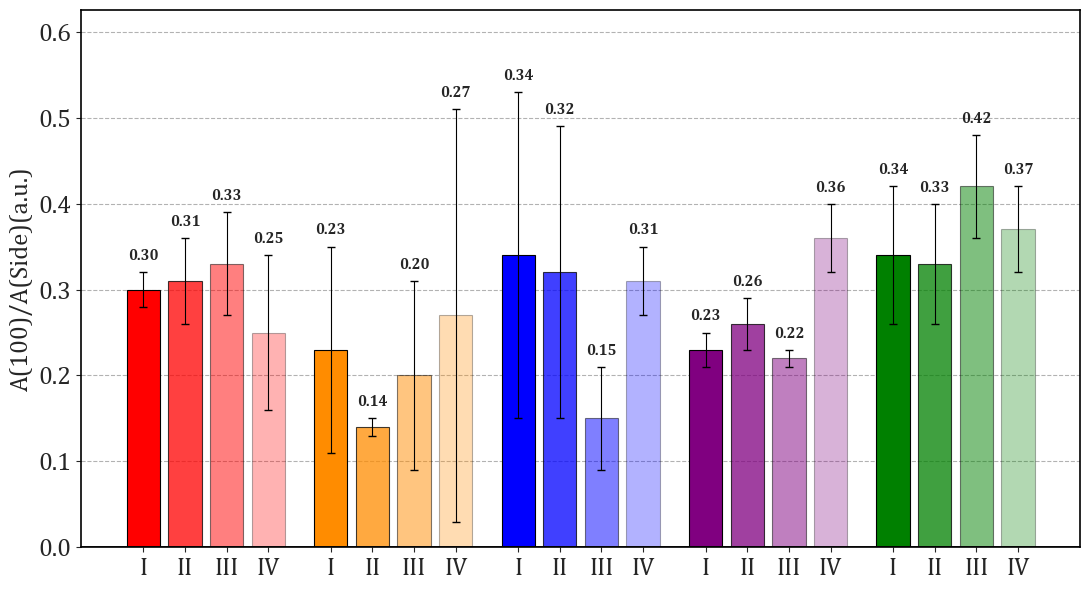

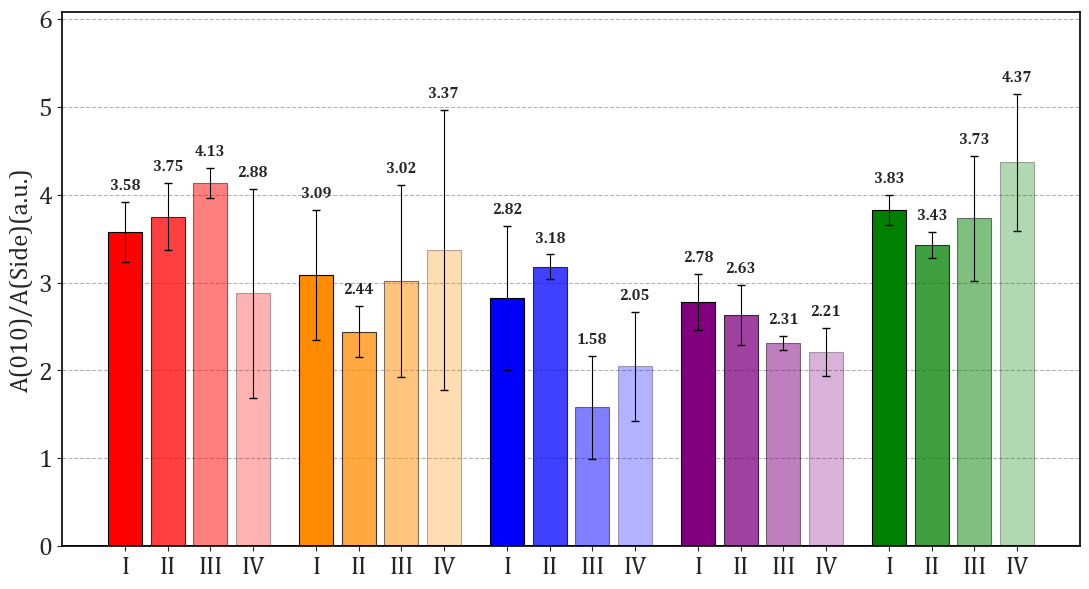

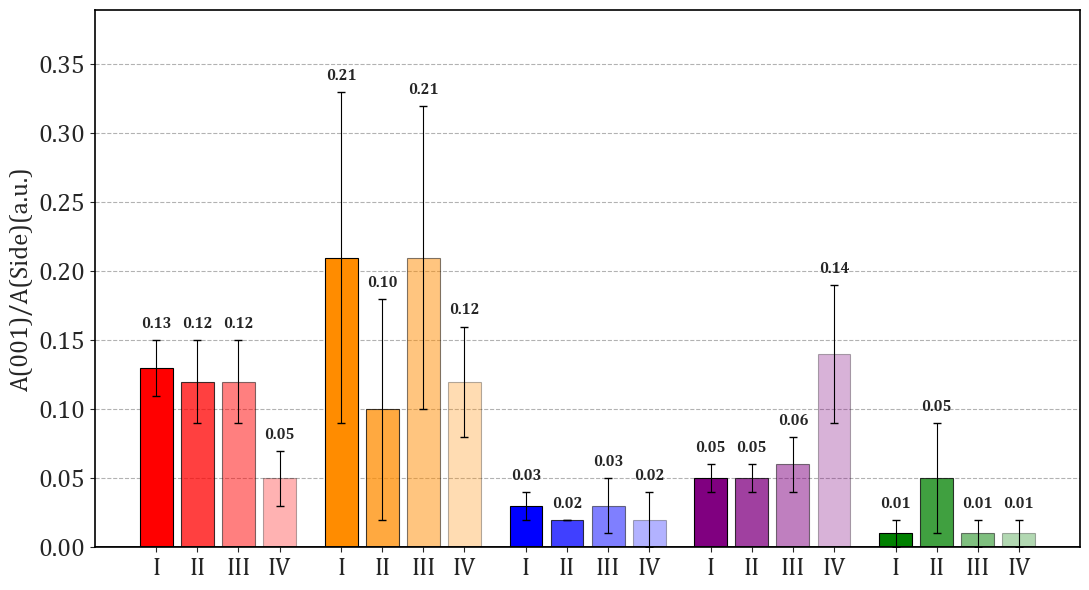

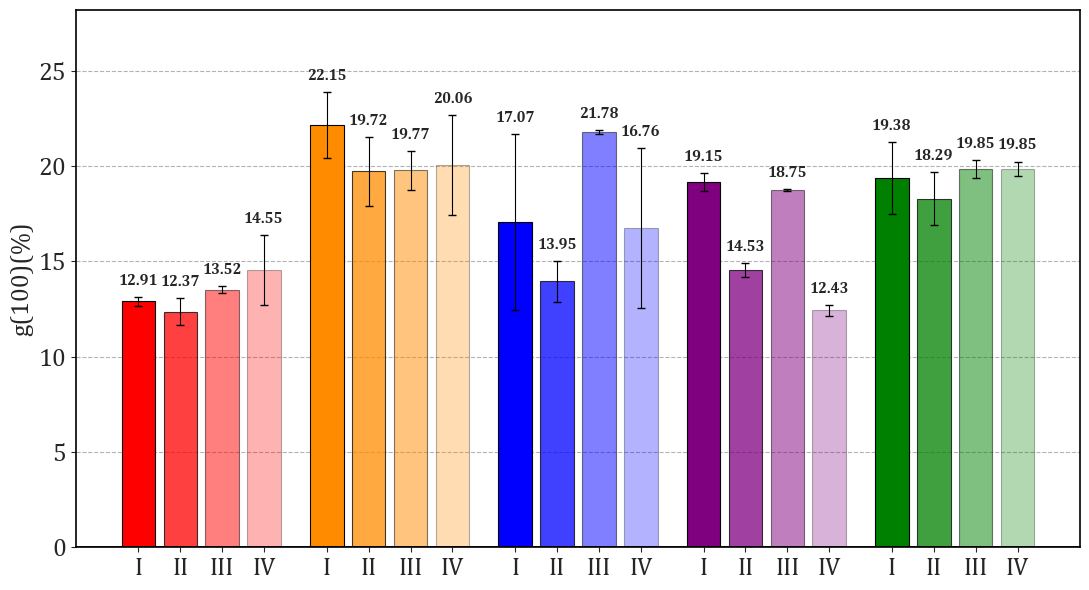

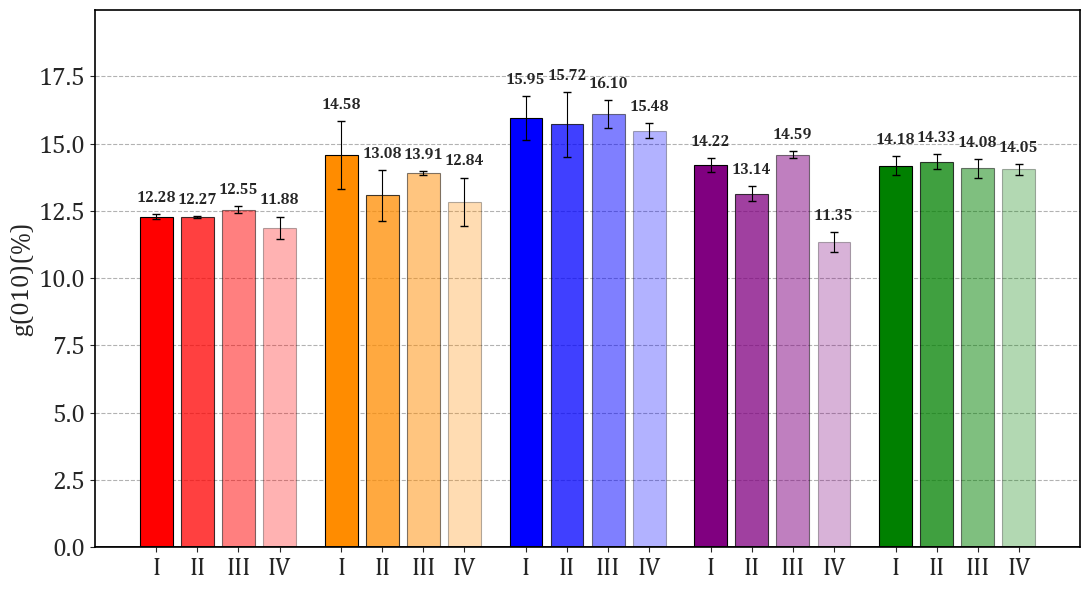

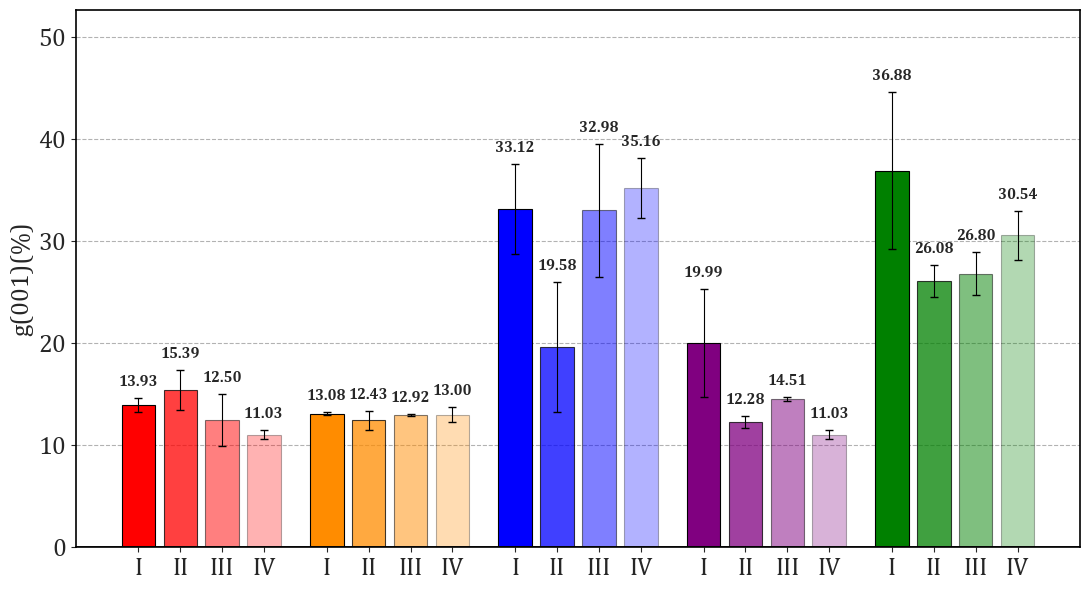

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN INICIAL ---
folder_name = 'tables'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Cambria", "Times New Roman"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Cambria"
})

solvent_order = ['DCB', 'CB', 'CF', 'TL', 'oXy']
color_map = {
    'DCB': 'red', 'CB': 'darkorange', 'CF': 'blue', 'TL': 'purple', 'oXy': 'green'
}

method_opacity = {'I': 1.0, 'II': 0.75, 'III': 0.50, 'IV': 0.30}
ancho_barra = 0.8  
espacio_entre_grupos = 1.5 

# --- 2. PROCESAMIENTO DE DATOS ---
# (Asumiendo que 'means' y 'stds' ya están definidos en tu entorno)
for df in [means, stds]:
    df['Solvent'] = pd.Categorical(df['Solvent'], categories=solvent_order, ordered=True)
    df.sort_values(['Solvent', 'Method'], inplace=True)
    df.reset_index(drop=True, inplace=True)

# Lógica de posicionamiento y etiquetas
nuevas_x = []
labels_solo_metodos = [] 
posicion_actual = 0

for i in range(len(means)):
    metodo = means['Method'].iloc[i]
    solvente = means['Solvent'].iloc[i]
    
    if i > 0 and solvente != means['Solvent'].iloc[i-1]:
        posicion_actual += espacio_entre_grupos
    else:
        posicion_actual += 1
    
    nuevas_x.append(posicion_actual)
    labels_solo_metodos.append(metodo) 

parameters = [col for col in means.columns if col not in ['Solvent', 'Method']]

# --- 3. BUCLE DE GRÁFICOS ---
for param in parameters:
    plt.figure(figsize=(11, 6))
    ax = plt.gca()
    
    ax.set_ymargin(0)
    ax.set_axisbelow(True) 
    plt.grid(axis='y', linestyle='--', alpha=0.3, color='black')

    # --- ESCALA Y NIVELACIÓN DEL CERO ---
    y_max_data = (means[param] + stds[param].fillna(0)).max()
    y_min_data = (means[param] - stds[param].fillna(0)).min()
    
    # Aumentamos el padding para dar espacio a las etiquetas de texto
    padding_sup = abs(y_max_data) * 0.18 if abs(y_max_data) > 0 else 0.8
    
    if y_min_data >= 0:
        limit_bottom = 0
    else:
        limit_bottom = y_min_data - (abs(y_min_data) * 0.1)

    ax.set_ylim(limit_bottom, y_max_data + padding_sup)

    # --- DIBUJO DE BARRAS Y ETIQUETAS ---
    for i in range(len(nuevas_x)):
        val_mean = means[param].iloc[i]
        val_std = stds[param].fillna(0).iloc[i]
        solvente = means['Solvent'].iloc[i]
        metodo = means['Method'].iloc[i]
        
        # Dibujar barra
        plt.bar(nuevas_x[i], val_mean, 
                yerr=val_std,
                error_kw={'elinewidth': 0.8, 'capsize': 3, 'ecolor': 'black'},
                color=color_map[solvente], 
                alpha=method_opacity[metodo],
                edgecolor='black', linewidth=0.8, width=ancho_barra)

        # SECCIÓN NUEVA: Añadir valor sobre la barra
        # Calculamos el punto más alto (barra o bigote de error)
        y_text_pos = val_mean + val_std if val_mean >= 0 else val_mean - val_std
        # Añadimos un pequeño margen dinámico para que no toque la línea
        v_offset = y_max_data * 0.02

        ax.text(nuevas_x[i], y_text_pos + v_offset, 
                f'{val_mean:.2f}', 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold',
                fontfamily='serif')

    # --- CONFIGURACIÓN DE EJES ---
    ax.axhline(0, color='black', linewidth=1.2)
    
    plt.xticks(nuevas_x, labels_solo_metodos, rotation=0, ha='center', fontsize=18)
    plt.ylabel(f'{param}', fontsize=18, fontweight='normal')
    plt.yticks(fontsize=18)

    # Bordes negros del gráfico
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Guardado
    clean_name = param.replace("(", "").replace(")", "").replace("/", "_").replace(" ", "_")
    plt.savefig(os.path.join(folder_name, f"plot_{clean_name}.png"), dpi=300, bbox_inches='tight')
    plt.show()